# Train UNet+ASPP — Multi-class softmax v3 (DINOv2 features)

## v3 vs v2 vs OLD

| Component | OLD (binary) | v2 (softmax) | **v3 (softmax + DINOv2)** |
|---|---|---|---|
| Input channels | 9 (RGB + 1 coarse + co_occ + 4 one_hot) | 8 (RGB + 4 coarse + co_occ) | **40** (RGB + 4 coarse + co_occ + 32 DINOv2) |
| Output | 1ch sigmoid, 4 forward/ảnh | 5ch softmax, 1 forward/ảnh | **5ch softmax, 1 forward/ảnh** |
| DINOv2 features | — | — | **ViT-S/14 frozen → 1x1 conv 384→32 learned** |
| CE | Standard | Focal γ=1.5 | Focal γ=1.5 |
| Tversky | Dice symmetric | Per-class (sofa 0.4/0.6, bicycle 0.55/0.45) | Per-class (giữ v2) |
| Sofa CE boost | — | ×1.3 | ×1.3 |
| Boundary λ bicycle | 2.5 | 2.0 | 2.0 |

## Lý do thêm DINOv2

SAM3 baseline có **chair-sofa confusion** (SAM3 prompt "sofa" fire trên chair pixels và ngược lại vì 2 class giống nhau semantically). UNet v2 không thể fix triệt để vì **RGB + 4 coarse không đủ discriminative signal** — RGB của chair vs sofa rất giống.

**DINOv2** (Meta, self-supervised trên 142M ảnh) học representation **phân biệt fine-grained class** cực mạnh. Cộng feature DINOv2 vào UNet input:
- Pixel chair thực sự: DINOv2 feature nằm trong "chair cluster", **xa** "sofa cluster".
- UNet thấy feature giống chair cluster → output chair, dù coarse_sofa fire.
- → Break tie ambiguous của SAM3 bằng semantic feature độc lập.

## Pipeline

```
Image (original)
   │
   ├──→ Resize 518×518 → ImageNet norm → DINOv2 ViT-S/14 forward (FROZEN)
   │         → patch tokens [1369, 384] → reshape [384, 37, 37]
   │         → cache dinov2_cache/{img_id}.npz (float16)
   │
   ├──→ SAM3 coarse 4 target class (từ coarse_cache/)
   ├──→ GT VOC2012 → co_occ union + label map
   └──→ Resize 512×512 → ImageNet norm → RGB

Concat input (8 channels at 512×512):
   [RGB(3) | coarse_table | coarse_sofa | coarse_chair | coarse_bicycle | co_occ]

Inside UNet v3 forward:
   dino_cache [384, 37, 37] → 1x1 conv (384→32, learned) → upsample bilinear → [32, 512, 512]
   → concat với 8ch → [40, 512, 512] → ResNet34 encoder (first conv 40→64)
   → ASPP → decoder → final head [5, 512, 512] → softmax
```

## Output 5 channels (logits → softmax)

```
ch 0: bg          (background)
ch 1: diningtable
ch 2: sofa
ch 3: chair
ch 4: bicycle
```

## Workflow chạy notebook

1. **Build DINOv2 cache** (Cell "Build DINOv2 cache" — chạy 1 lần, ~5-10 phút GPU):
   - Load DINOv2 ViT-S/14 frozen.
   - Mỗi image_id → forward → save `dinov2_cache/{img_id}.npz` (key `features`, shape (384, 37, 37), float16).
   - Skip nếu file đã tồn tại.
2. **Train** (Cell "Training Loop"): dataset load DINOv2 cache cùng với SAM3 coarse + GT.
3. **Checkpoint**: `weights_aspp_new_v3/unet_aspp_new_v3_best.pth`, `arch_version='multi_class_softmax_v3_dinov2'`.

Eval notebooks (`eval_5class_unet_aspp_new_v3.ipynb`, `test-all-with-unetaspp-devin-v2-new_v3.ipynb`) tính DINOv2 on-the-fly (không cần cache lúc eval).


In [1]:
%pip install -q tqdm pillow matplotlib "albumentations>=2.0" opencv-python-headless scipy


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, json, time, random, math
from pathlib import Path
from contextlib import nullcontext

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from scipy.ndimage import distance_transform_edt
from tqdm.auto import tqdm

import albumentations as A
print('Albumentations:', A.__version__)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import torchvision.models as tvm
from torchvision.models import ResNet34_Weights
from torch.utils.data import Dataset, DataLoader

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch :', torch.__version__)
print('Device  :', DEVICE)
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))


Albumentations: 2.0.8
PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4


In [3]:
# ─── Paths ────────────────────────────────────────────────────────────────────
VOC_ROOT         = Path('/kaggle/input/datasets/tunmaixun/voc2012/VOCdevkit/VOC2012')
JPEG_DIR         = VOC_ROOT / 'JPEGImages'
MASK_DIR         = VOC_ROOT / 'SegmentationClass'
ID_LIST_PATH     = Path('/kaggle/input/datasets/tunmaixun/training/voc2012_4class_train_image_ids.txt')
COARSE_CACHE_DIR = Path('/kaggle/input/datasets/tunmaixun/coarse/coarse_cache')     # SAM3 coarse mask (input cho UNet)
DINOV2_CACHE_DIR = Path('dinov2_cache')     # DINOv2 features (input cho UNet)
DINOV2_CACHE_DIR.mkdir(parents=True, exist_ok=True)

WEIGHTS_DIR  = Path('weights_aspp_new_v3')
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
BEST_CKPT    = WEIGHTS_DIR / 'unet_aspp_new_v3_best.pth'
LAST_CKPT    = WEIGHTS_DIR / 'unet_aspp_new_v3_last.pth'
HISTORY_JSON = WEIGHTS_DIR / 'unet_aspp_new_v3_history.json'

# ─── VOC class mapping ────────────────────────────────────────────────────────
VOC_CLASSES = [
    'aeroplane','bicycle','bird','boat','bottle',
    'bus','car','cat','chair','cow',
    'diningtable','dog','horse','motorbike','person',
    'pottedplant','sheep','sofa','train','tvmonitor',
]
VOC_CLASS_TO_IDX = {name: i + 1 for i, name in enumerate(VOC_CLASSES)}

# ─── Target classes (order = local index in softmax output) ───────────────────
# ch 0 = bg, ch 1..4 = diningtable / sofa / chair / bicycle
TARGET_CLASSES  = ['diningtable', 'sofa', 'chair', 'bicycle']
TARGET_TO_VOC   = {name: VOC_CLASS_TO_IDX[name] for name in TARGET_CLASSES}
TARGET_TO_LOCAL = {name: i + 1 for i, name in enumerate(TARGET_CLASSES)}
LOCAL_TO_TARGET = {v: k for k, v in TARGET_TO_LOCAL.items()}
NUM_TARGETS     = len(TARGET_CLASSES)
NUM_OUT_CLASSES = NUM_TARGETS + 1

# Co-occurrence classes (GT union → input ch 7)
CO_OCC_CLASSES = ['person', 'cat', 'dog', 'bottle', 'pottedplant']
CO_OCC_VOC_IDX = [VOC_CLASS_TO_IDX[c] for c in CO_OCC_CLASSES]

# ─── DINOv2 config ─────────────────────────────────────────────────────────────
# ViT-S/14 (21M params) — nhẹ + đủ mạnh cho fine-grained class distinction.
DINOV2_MODEL_NAME = 'dinov2_vits14'
DINOV2_EMBED_DIM  = 384          # ViT-S/14 output dim
DINOV2_PATCH_SIZE = 14
DINOV2_INPUT_SIZE = 518          # 518 / 14 = 37 patches per side → 37×37 grid
DINOV2_GRID_SIZE  = DINOV2_INPUT_SIZE // DINOV2_PATCH_SIZE   # 37
DINOV2_COMPRESS   = 32           # Channel sau 1x1 conv 384→32 (learned, in model)

# ─── Input channel design (at 512×512 resolution) ─────────────────────────────
# Trong dataset ta trả 8ch giống v2 + DINOv2 raw feature cached [384, 37, 37].
# Model forward tự upsample + compress DINOv2 → concat thành 40ch.
IN_CHANNELS_8  = 3 + NUM_TARGETS + 1                     # RGB + 4 coarse + co_occ = 8
IN_CHANNELS_40 = IN_CHANNELS_8 + DINOV2_COMPRESS         # sau DINOv2 path = 40

# ─── Hyperparameters (GIỮ NGUYÊN từ v2) ───────────────────────────────────────
SEED             = 42
IMAGE_SIZE       = 512
BATCH_SIZE       = 4
EPOCHS           = 25
WARMUP_EPOCHS    = 1
LR               = 1e-4
WEIGHT_DECAY     = 1e-4
NUM_WORKERS      = 0 if os.name == 'nt' else 4

BOUNDARY_LAMBDA = {
    'diningtable': 0.3,
    'sofa'       : 0.3,
    'chair'      : 0.5,
    'bicycle'    : 2.0,
}

TVERSKY_PARAMS = {
    'diningtable': (0.5, 0.5),
    'sofa'       : (0.4, 0.6),
    'chair'      : (0.5, 0.5),
    'bicycle'    : (0.55, 0.45),
}

SOFA_CE_BOOST  = 1.3
FOCAL_GAMMA    = 1.5

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(SEED)

with open(ID_LIST_PATH) as f:
    listed_ids = list(dict.fromkeys(x.strip() for x in f if x.strip()))

print(f'Listed IDs    : {len(listed_ids)}')
print(f'Target classes (local 1..4): {TARGET_CLASSES}')
print(f'Output classes: bg(0) + {", ".join(f"{c}({i})" for i,c in enumerate(TARGET_CLASSES, 1))}')
print(f'Co-occ classes: {CO_OCC_CLASSES}')
print(f'DINOv2        : {DINOV2_MODEL_NAME}, embed_dim={DINOV2_EMBED_DIM}, input={DINOV2_INPUT_SIZE}×{DINOV2_INPUT_SIZE}, grid={DINOV2_GRID_SIZE}×{DINOV2_GRID_SIZE}')
print(f'DINOv2 compress: {DINOV2_EMBED_DIM} → {DINOV2_COMPRESS} (1x1 conv, learned in model)')
print(f'IN_CHANNELS   : {IN_CHANNELS_8} (dataset) → {IN_CHANNELS_40} (after DINOv2 in model)')
print(f'OUT_CLASSES   : {NUM_OUT_CLASSES}  (bg + 4 target)')
print(f'Epochs        : {EPOCHS}  (warmup={WARMUP_EPOCHS} + cosine)')
print(f'Tversky params (per class): {TVERSKY_PARAMS}')
print(f'Boundary lambda: {BOUNDARY_LAMBDA}')
print(f'Sofa CE boost  : x{SOFA_CE_BOOST}')
print(f'Focal gamma    : {FOCAL_GAMMA}')


Listed IDs    : 299
Target classes (local 1..4): ['diningtable', 'sofa', 'chair', 'bicycle']
Output classes: bg(0) + diningtable(1), sofa(2), chair(3), bicycle(4)
Co-occ classes: ['person', 'cat', 'dog', 'bottle', 'pottedplant']
DINOv2        : dinov2_vits14, embed_dim=384, input=518×518, grid=37×37
DINOv2 compress: 384 → 32 (1x1 conv, learned in model)
IN_CHANNELS   : 8 (dataset) → 40 (after DINOv2 in model)
OUT_CLASSES   : 5  (bg + 4 target)
Epochs        : 25  (warmup=1 + cosine)
Tversky params (per class): {'diningtable': (0.5, 0.5), 'sofa': (0.4, 0.6), 'chair': (0.5, 0.5), 'bicycle': (0.55, 0.45)}
Boundary lambda: {'diningtable': 0.3, 'sofa': 0.3, 'chair': 0.5, 'bicycle': 2.0}
Sofa CE boost  : x1.3
Focal gamma    : 1.5


In [4]:
# ─── Validate IDs: jpg + gt_mask + SAM3 coarse npz ────────────────────────────
def check_id_ready(image_id):
    for path, tag in [
        (JPEG_DIR / f'{image_id}.jpg',         'missing_jpg'),
        (MASK_DIR / f'{image_id}.png',         'missing_gt'),
        (COARSE_CACHE_DIR / f'{image_id}.npz', 'missing_coarse_npz'),
    ]:
        if not path.exists(): return False, tag
    try:
        with np.load(COARSE_CACHE_DIR / f'{image_id}.npz') as d:
            miss = set(TARGET_CLASSES) - set(d.files)
            if miss: return False, f'missing_keys:{sorted(miss)}'
        return True, 'ok'
    except Exception as e:
        return False, f'corrupt:{e}'

valid_ids, skipped = [], []
for image_id in tqdm(listed_ids, desc='Validate IDs'):
    ok, reason = check_id_ready(image_id)
    (valid_ids if ok else skipped).append(image_id if ok else (image_id, reason))

print(f'Usable  : {len(valid_ids)}/{len(listed_ids)}')
print(f'Skipped : {len(skipped)}')
for item in skipped[:5]:
    print(f'  {item}')
if not valid_ids:
    raise RuntimeError('No usable IDs.')


Validate IDs:   0%|          | 0/299 [00:00<?, ?it/s]

Usable  : 299/299
Skipped : 0


In [5]:
# ─── Build DINOv2 cache (1 lần) ───────────────────────────────────────────────
# Mỗi image_id → forward DINOv2 frozen → lưu features [384, 37, 37] (float16) vào
# dinov2_cache/{image_id}.npz (key 'features'). Skip nếu file đã tồn tại.
#
# Chạy ~5-10 phút trên GPU cho 1464 ảnh.
# KHÔNG train DINOv2 ở đây — chỉ inference + cache. Compression 384→32 sẽ được
# trained bên trong UNet model (1x1 conv learned).
#
# Kaggle lưu ý: torch.hub.load yêu cầu internet. Nếu notebook không có internet,
# upload DINOv2 repo + weights thành Kaggle dataset và load offline.

print('Loading DINOv2...')
# Torch hub: nếu notebook có internet → auto download vào ~/.cache/torch/hub.
# Nếu không có internet, set TORCH_HOME đến path local chứa repo đã tải.
try:
    dinov2_model = torch.hub.load(
        'facebookresearch/dinov2', DINOV2_MODEL_NAME, trust_repo=True)
except Exception as e:
    print(f'torch.hub.load failed: {e}')
    print('Fallback: thử load từ Kaggle dataset input...')
    # Kaggle offline: repo thường ở /kaggle/input/dinov2-repo, weights ở
    # /kaggle/input/dinov2-weights/dinov2_vits14_pretrain.pth
    import sys
    dinov2_repo_candidates = [
        Path('/kaggle/input/dinov2-repo'),
        Path('/kaggle/input/models/xuantuan/dinov2/pytorch/default/1'),
        Path.home() / '.cache' / 'torch' / 'hub' / 'facebookresearch_dinov2_main',
    ]
    repo_path = next((p for p in dinov2_repo_candidates if p.exists()), None)
    if repo_path is None:
        raise RuntimeError(
            f'DINOv2 repo not found. Tried: {dinov2_repo_candidates}. '
            'Please enable internet or upload DINOv2 repo as Kaggle dataset.'
        )
    sys.path.insert(0, str(repo_path))
    from dinov2.hub.backbones import dinov2_vits14 as _dinov2_build
    dinov2_model = _dinov2_build(pretrained=False)
    # Tìm weights
    w_candidates = [
        Path('/kaggle/input/models/xuantuan/dinov2/pytorch/default/1/dinov2_vits14_pretrain.pth'),
        repo_path / 'dinov2_vits14_pretrain.pth',
    ]
    wpath = next((p for p in w_candidates if p.exists()), None)
    if wpath is None:
        raise RuntimeError(f'DINOv2 weights not found. Tried: {w_candidates}')
    sd = torch.load(wpath, map_location='cpu')
    dinov2_model.load_state_dict(sd)
    print(f'Loaded DINOv2 weights from {wpath}')

dinov2_model = dinov2_model.to(DEVICE).eval()
for p in dinov2_model.parameters():
    p.requires_grad = False

n_params = sum(p.numel() for p in dinov2_model.parameters())
print(f'DINOv2 {DINOV2_MODEL_NAME} loaded ({n_params:,} params, frozen)')

@torch.no_grad()
def dinov2_forward(image_pil):
    """
    Image PIL → DINOv2 patch tokens → feature map [384, 37, 37] (float16 cpu numpy).
    """
    img_r = image_pil.convert('RGB').resize((DINOV2_INPUT_SIZE, DINOV2_INPUT_SIZE), Image.BILINEAR)
    x = TF.normalize(TF.to_tensor(img_r), IMAGENET_MEAN, IMAGENET_STD).unsqueeze(0).to(DEVICE)
    # forward_features trả dict với 'x_norm_patchtokens' shape [1, num_patches, embed_dim]
    out = dinov2_model.forward_features(x)
    tokens = out['x_norm_patchtokens']   # [1, 1369, 384]
    B, N, D = tokens.shape
    assert N == DINOV2_GRID_SIZE * DINOV2_GRID_SIZE, f'Expected {DINOV2_GRID_SIZE**2} tokens, got {N}'
    assert D == DINOV2_EMBED_DIM, f'Expected {DINOV2_EMBED_DIM} dim, got {D}'
    # Reshape → [1, 384, 37, 37]
    feat = tokens.transpose(1, 2).reshape(B, D, DINOV2_GRID_SIZE, DINOV2_GRID_SIZE)
    return feat.squeeze(0).to(torch.float16).cpu().numpy()

# Cache loop
n_cached = 0
n_new    = 0
errors   = []

for image_id in tqdm(valid_ids, desc='Build DINOv2 cache'):
    out_path = DINOV2_CACHE_DIR / f'{image_id}.npz'
    if out_path.exists():
        # Sanity check shape
        try:
            with np.load(out_path) as d:
                f = d['features']
                if f.shape == (DINOV2_EMBED_DIM, DINOV2_GRID_SIZE, DINOV2_GRID_SIZE):
                    n_cached += 1
                    continue
        except Exception:
            pass   # corrupt → re-compute

    try:
        image_pil = Image.open(JPEG_DIR / f'{image_id}.jpg')
        feat = dinov2_forward(image_pil)   # [384, 37, 37] float16
        np.savez_compressed(out_path, features=feat)
        n_new += 1
    except Exception as e:
        errors.append((image_id, str(e)))

print(f'\nDINOv2 cache: {n_cached} already existed, {n_new} new, {len(errors)} errors')
if errors:
    for e in errors[:5]: print(f'  {e}')

# Free DINOv2 model from GPU (không cần trong training — chỉ dùng cache)
del dinov2_model
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('DINOv2 model unloaded from GPU (freed memory for UNet training)')


Loading DINOv2...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 538MB/s]


DINOv2 dinov2_vits14 loaded (22,056,576 params, frozen)


Build DINOv2 cache:   0%|          | 0/299 [00:00<?, ?it/s]


DINOv2 cache: 0 already existed, 299 new, 0 errors
DINOv2 model unloaded from GPU (freed memory for UNet training)


In [6]:
# ─── Scan GT to: filter image-level positives + compute CE class weights ──────
# Sample = 1 image (có ≥1 target class trong GT).
# CE class weights = inverse-frequency, normalize mean=1, sofa boost ×SOFA_CE_BOOST.

cls_pixels = {c: 0 for c in range(NUM_OUT_CLASSES)}

train_ids = []
total_target_present = {c: 0 for c in TARGET_CLASSES}

for image_id in tqdm(valid_ids, desc='Scan GT for CE weights'):
    gt_np = np.array(Image.open(MASK_DIR / f'{image_id}.png'), dtype=np.uint8)
    valid = gt_np != 255
    has_target = False
    for cls_name, local_id in TARGET_TO_LOCAL.items():
        voc_idx  = TARGET_TO_VOC[cls_name]
        cls_mask = (gt_np == voc_idx) & valid
        p = int(cls_mask.sum())
        if p > 0:
            cls_pixels[local_id] += p
            total_target_present[cls_name] += 1
            has_target = True
    if has_target:
        train_ids.append(image_id)
        v_total = int(valid.sum())
        target_total = sum(
            int(((gt_np == TARGET_TO_VOC[c]) & valid).sum())
            for c in TARGET_CLASSES
        )
        cls_pixels[0] += v_total - target_total

# Lọc thêm: chỉ giữ ảnh có DINOv2 cache
train_ids_final = []
for image_id in train_ids:
    if (DINOV2_CACHE_DIR / f'{image_id}.npz').exists():
        train_ids_final.append(image_id)
n_missing_dino = len(train_ids) - len(train_ids_final)
if n_missing_dino:
    print(f'WARN: {n_missing_dino} train images missing DINOv2 cache → skipped')
train_ids = train_ids_final

print(f'\nTrain images (có ≥1 target + DINOv2 cache): {len(train_ids)}')
print('Per-class image count:')
for cls in TARGET_CLASSES:
    print(f'  {cls:11s}: {total_target_present[cls]:4d} images')

print('\nPixel counts (in train set):')
total = sum(cls_pixels.values())
for c in range(NUM_OUT_CLASSES):
    name = 'bg' if c == 0 else LOCAL_TO_TARGET[c]
    pct = 100.0 * cls_pixels[c] / max(total, 1)
    print(f'  ch {c} ({name:11s}): {cls_pixels[c]:>14,d} px  ({pct:5.2f}%)')

freq = np.array([cls_pixels[c] for c in range(NUM_OUT_CLASSES)], dtype=np.float64)
inv  = 1.0 / np.clip(freq, 1, None)
inv  = inv / inv.mean()
inv  = np.clip(inv, 0.2, 5.0)
inv  = inv / inv.mean()

sofa_local = TARGET_TO_LOCAL['sofa']
inv[sofa_local] *= SOFA_CE_BOOST
inv  = inv / inv.mean()

CE_WEIGHTS = torch.tensor(inv, dtype=torch.float32, device=DEVICE)

print(f'\nCE class weights (clipped to [0.2, 5.0], sofa boosted x{SOFA_CE_BOOST}, mean=1):')
for c in range(NUM_OUT_CLASSES):
    name = 'bg' if c == 0 else LOCAL_TO_TARGET[c]
    print(f'  ch {c} ({name:11s}): weight = {CE_WEIGHTS[c].item():.3f}')

BOUNDARY_LAMBDA_TENSOR = torch.tensor(
    [BOUNDARY_LAMBDA[c] for c in TARGET_CLASSES],
    dtype=torch.float32, device=DEVICE,
)
TVERSKY_TENSOR = torch.tensor(
    [TVERSKY_PARAMS[c] for c in TARGET_CLASSES],
    dtype=torch.float32, device=DEVICE,
)


Scan GT for CE weights:   0%|          | 0/299 [00:00<?, ?it/s]


Train images (có ≥1 target + DINOv2 cache): 299
Per-class image count:
  diningtable:   82 images
  sofa       :   93 images
  chair      :  148 images
  bicycle    :   65 images

Pixel counts (in train set):
  ch 0 (bg         ):     39,573,994 px  (78.85%)
  ch 1 (diningtable):      3,381,632 px  ( 6.74%)
  ch 2 (sofa       ):      3,612,229 px  ( 7.20%)
  ch 3 (chair      ):      2,861,091 px  ( 5.70%)
  ch 4 (bicycle    ):        758,311 px  ( 1.51%)

CE class weights (clipped to [0.2, 5.0], sofa boosted x1.3, mean=1):
  ch 0 (bg         ): weight = 0.188
  ch 1 (diningtable): weight = 0.612
  ch 2 (sofa       ): weight = 0.745
  ch 3 (chair      ): weight = 0.724
  ch 4 (bicycle    ): weight = 2.731


In [7]:
# ─── Dataset: 1 image = 1 sample, multi-class label map + DINOv2 cache ────────
# Augmentation: HorizontalFlip + RandomScale + ColorJitter (giữ giống v2).
# DINOv2 features KHÔNG augment (áp dụng tại resolution 37×37, độc lập với ảnh gốc
# sau aug). Lý do: nếu aug flip/crop ảnh, DINOv2 feature của ảnh aug sẽ khác với
# DINOv2 feature của ảnh gốc → phải re-run DINOv2 → quá chậm. Thay vào đó:
#   - Dùng DINOv2 feature của ảnh GỐC (không aug).
#   - Với HorizontalFlip: nếu aug flip, flip luôn DINOv2 feature (cheap).
#   - Với RandomScale + RandomCrop: bỏ qua aug này khi có DINOv2? Không — ta
#     ÁP dụng aug lên ảnh RGB như thường, DINOv2 feature giữ nguyên (feature
#     chỉ cung cấp semantic prior, không cần exact alignment pixel-level).
#
# Cách tiếp cận: DINOv2 feature coi như GLOBAL semantic context, không đòi pixel
# perfect alignment với ảnh aug. Model tự học cách dùng feature như hint.

def build_augment():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomScale(scale_limit=(-0.25, 0.25), p=0.7),
        A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE,
                      border_mode=cv2.BORDER_CONSTANT, value=0,
                      mask_value=255, p=1.0),
        A.RandomCrop(height=IMAGE_SIZE, width=IMAGE_SIZE, p=1.0),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.08, p=0.6),
    ])

def compute_boundary_weight(target_np, alpha=1.5):
    gt = target_np.astype(bool)
    if not gt.any() or gt.all():
        return np.ones(target_np.shape, dtype=np.float32)
    d_in  = distance_transform_edt(gt)
    d_out = distance_transform_edt(~gt)
    dist  = (d_in + d_out).astype(np.float32)
    w     = 1.0 / (dist + 1.0) ** alpha
    w_max = w.max()
    return (w / w_max).astype(np.float32) if w_max > 0 else w


class SAM3MultiClassDatasetV3(Dataset):
    """
    Mỗi sample = 1 image_id có ≥1 target class trong GT + DINOv2 cache.

    Returns:
      input_8ch    : [8, H, W] = RGB(3) + 4 coarse + co_occ (đã aug)
      dino_feat    : [384, 37, 37] — DINOv2 feature của ảnh GỐC (chưa aug).
                     HorizontalFlip aug sẽ flip dino_feat tương ứng.
                     RandomScale + Crop + ColorJitter KHÔNG ảnh hưởng dino_feat
                     (ta coi dino như global semantic prior).
      target_label : [H, W] long — values 0..4 (ignore mapped to 0 + valid mask)
      valid        : [1, H, W] float
      coarses      : [4, H, W] float — để tính baseline IoU
      bnd_w        : [4, H, W] float — boundary weight map cho từng target class
      image_id     : str
    """
    def __init__(self, image_ids, coarse_dir, dinov2_dir, aug=None):
        self.image_ids  = image_ids
        self.coarse_dir = Path(coarse_dir)
        self.dinov2_dir = Path(dinov2_dir)
        self.aug = aug

    def __len__(self): return len(self.image_ids)

    def _load_coarses(self, image_id):
        with np.load(self.coarse_dir / f'{image_id}.npz') as d:
            arrs = [d[cls].astype(np.uint8) for cls in TARGET_CLASSES]
        return np.stack(arrs, axis=0)

    def _load_dinov2(self, image_id):
        with np.load(self.dinov2_dir / f'{image_id}.npz') as d:
            feat = d['features'].astype(np.float32)   # (384, 37, 37)
        return feat

    def _build_co_occ(self, gt_np):
        co_occ = np.zeros(gt_np.shape, dtype=np.uint8)
        for voc_idx in CO_OCC_VOC_IDX:
            co_occ |= (gt_np == voc_idx).astype(np.uint8)
        return co_occ

    def _build_label_map(self, gt_np):
        label = np.zeros(gt_np.shape, dtype=np.uint8)
        for cls_name in TARGET_CLASSES:
            voc_idx  = TARGET_TO_VOC[cls_name]
            local_id = TARGET_TO_LOCAL[cls_name]
            label[gt_np == voc_idx] = local_id
        return label

    def __getitem__(self, idx):
        image_id  = self.image_ids[idx]
        image_np  = np.array(Image.open(JPEG_DIR / f'{image_id}.jpg').convert('RGB'))
        gt_np     = np.array(Image.open(MASK_DIR / f'{image_id}.png'), dtype=np.uint8)
        coarses_np= self._load_coarses(image_id)        # (4, H, W) uint8
        dino_feat = self._load_dinov2(image_id)          # (384, 37, 37) float32

        # Resize tất cả về IMAGE_SIZE
        image_np  = cv2.resize(image_np,  (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_LINEAR)
        gt_np     = cv2.resize(gt_np,     (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
        coarses_resized = []
        for c in range(NUM_TARGETS):
            coarses_resized.append(
                cv2.resize(coarses_np[c], (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
            )
        coarses_np = np.stack(coarses_resized, axis=0)

        valid_np  = (gt_np != 255).astype(np.uint8)
        co_occ_np = self._build_co_occ(gt_np)
        label_np  = self._build_label_map(gt_np)

        # Augment: RGB + masks (label + valid + co_occ + 4 coarses)
        masks_to_aug = [
            label_np, valid_np, co_occ_np,
            coarses_np[0], coarses_np[1], coarses_np[2], coarses_np[3],
        ]
        flipped = False
        if self.aug is not None:
            # Track flip qua param 'flip_applied' — albumentations không expose
            # trực tiếp. Hack: sample HFlip riêng, rồi áp dụng các aug còn lại.
            # Cách dễ hơn: tự code HFlip, sau đó gọi aug không có HFlip.
            if random.random() < 0.5:
                image_np = image_np[:, ::-1].copy()
                for i in range(len(masks_to_aug)):
                    masks_to_aug[i] = masks_to_aug[i][:, ::-1].copy()
                # Flip DINOv2 feature theo width (axis=2)
                dino_feat = dino_feat[:, :, ::-1].copy()
                flipped = True

            # Apply các aug còn lại (không HFlip)
            out = self.aug(image=image_np, masks=masks_to_aug)
            image_np   = out['image']
            (label_np, valid_np, co_occ_np,
             c0, c1, c2, c3) = out['masks']
            coarses_np = np.stack([c0, c1, c2, c3], axis=0)

        label_np  = np.asarray(label_np,  dtype=np.uint8)
        valid_np  = (np.asarray(valid_np)  > 0).astype(np.float32)
        co_occ_np = (np.asarray(co_occ_np) > 0).astype(np.float32)
        coarses_np= (np.asarray(coarses_np) > 0).astype(np.float32)

        pad_mask = label_np > (NUM_OUT_CLASSES - 1)
        valid_np = valid_np * (~pad_mask).astype(np.float32)
        label_np = label_np.copy()
        label_np[pad_mask] = 0

        bnd_w = np.zeros((NUM_TARGETS, IMAGE_SIZE, IMAGE_SIZE), dtype=np.float32)
        for c in range(NUM_TARGETS):
            local_id = c + 1
            cls_bin = (label_np == local_id).astype(np.uint8)
            bnd_w[c] = compute_boundary_weight(cls_bin)

        rgb       = TF.normalize(TF.to_tensor(image_np), IMAGENET_MEAN, IMAGENET_STD)
        coarses_t = torch.from_numpy(coarses_np)
        co_occ_t  = torch.from_numpy(co_occ_np).unsqueeze(0)
        inp_8ch   = torch.cat([rgb, coarses_t, co_occ_t], dim=0)

        return {
            'input_8ch'   : inp_8ch,                                        # [8, 512, 512]
            'dino_feat'   : torch.from_numpy(dino_feat.astype(np.float32)), # [384, 37, 37]
            'target_label': torch.from_numpy(label_np.astype(np.int64)),
            'valid'       : torch.from_numpy(valid_np).unsqueeze(0),
            'coarses'     : coarses_t,
            'bnd_w'       : torch.from_numpy(bnd_w),
            'image_id'    : image_id,
        }

# Build augment without HFlip (ta đã handle ngoài)
def build_augment_no_hflip():
    return A.Compose([
        A.RandomScale(scale_limit=(-0.25, 0.25), p=0.7),
        A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE,
                      border_mode=cv2.BORDER_CONSTANT, value=0,
                      mask_value=255, p=1.0),
        A.RandomCrop(height=IMAGE_SIZE, width=IMAGE_SIZE, p=1.0),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.08, p=0.6),
    ])

train_ds = SAM3MultiClassDatasetV3(train_ids, COARSE_CACHE_DIR, DINOV2_CACHE_DIR, aug=build_augment_no_hflip())
viz_ds   = SAM3MultiClassDatasetV3(train_ids, COARSE_CACHE_DIR, DINOV2_CACHE_DIR, aug=None)

print(f'Train samples: {len(train_ds)}')
b = train_ds[0]
assert b['input_8ch'].shape == (IN_CHANNELS_8, IMAGE_SIZE, IMAGE_SIZE)
assert b['dino_feat'].shape == (DINOV2_EMBED_DIM, DINOV2_GRID_SIZE, DINOV2_GRID_SIZE)
assert b['target_label'].shape == (IMAGE_SIZE, IMAGE_SIZE)
assert b['bnd_w'].shape == (NUM_TARGETS, IMAGE_SIZE, IMAGE_SIZE)
print(f"Sample[0]: image_id={b['image_id']}")
print(f"  input_8ch    : {tuple(b['input_8ch'].shape)}  (RGB+coarse+co_occ)")
print(f"  dino_feat    : {tuple(b['dino_feat'].shape)}  range [{float(b['dino_feat'].min()):.3f}, {float(b['dino_feat'].max()):.3f}]")
print(f"  target_label : {tuple(b['target_label'].shape)}  unique: {sorted(b['target_label'].unique().tolist())}")
print(f"  valid        : {tuple(b['valid'].shape)}  fg={float(b['valid'].mean()):.4f}")
print(f"  coarses      : {tuple(b['coarses'].shape)}  fg per-class: {[float(b['coarses'][c].mean()) for c in range(4)]}")
print(f"  bnd_w        : {tuple(b['bnd_w'].shape)}  range: [{float(b['bnd_w'].min()):.3f}, {float(b['bnd_w'].max()):.3f}]")


Train samples: 299
Sample[0]: image_id=2007_000063
  input_8ch    : (8, 512, 512)  (RGB+coarse+co_occ)
  dino_feat    : (384, 37, 37)  range [-21.125, 14.867]
  target_label : (512, 512)  unique: [0, 3]
  valid        : (1, 512, 512)  fg=0.9531
  coarses      : (4, 512, 512)  fg per-class: [0.0, 0.0, 0.4172630310058594, 0.0]
  bnd_w        : (4, 512, 512)  range: [0.002, 1.000]


/tmp/ipykernel_57/2945630129.py:167: UserWarning: Argument(s) 'value, mask_value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE,


In [8]:
# ─── ASPP Module (giữ GroupNorm cho GAP branch) ───────────────────────────────
class ASPP(nn.Module):
    def __init__(self, in_ch=512, out_ch=256):
        super().__init__()
        def _branch(dilation):
            if dilation == 1:
                return nn.Sequential(
                    nn.Conv2d(in_ch, out_ch, 1, bias=False),
                    nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=dilation,
                          dilation=dilation, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))

        self.b1  = _branch(1)
        self.b6  = _branch(6)
        self.b12 = _branch(12)
        self.b18 = _branch(18)

        self.gap = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.GroupNorm(32, out_ch),
            nn.ReLU(inplace=True))

        self.project = nn.Sequential(
            nn.Conv2d(out_ch * 5, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Dropout2d(0.1))

    def forward(self, x):
        h, w = x.shape[-2:]
        gap  = F.interpolate(self.gap(x), size=(h, w),
                             mode='bilinear', align_corners=False)
        return self.project(torch.cat(
            [self.b1(x), self.b6(x), self.b12(x), self.b18(x), gap], dim=1))


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch // 2 + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([skip, x], dim=1))


class ResNet34UNetASPPMultiV3(nn.Module):
    """
    v3: ResNet-34 + ASPP + UNet decoder + DINOv2 feature branch.

    Input:
      - input_8ch : [B, 8, 512, 512]  = RGB + 4 coarse + co_occ
      - dino_feat : [B, 384, 37, 37]  = DINOv2 ViT-S/14 features (frozen, from cache)

    DINOv2 branch (learned):
      1x1 conv 384 → 32 → upsample bilinear → [B, 32, 512, 512]

    Main path:
      Concat(input_8ch, dino_compressed) = [B, 40, 512, 512] → ResNet first conv.

    First conv init:
      - ch 0-2  : ImageNet pretrained RGB weights
      - ch 3-7  : 0 (coarse + co_occ)
      - ch 8-39 : 0 (DINOv2 compressed, learned 1x1 also starts random → small init)
    """
    def __init__(self, in_channels_8=8, dinov2_dim=384, dinov2_compress=32, out_channels=5):
        super().__init__()
        self.in_channels_8    = in_channels_8
        self.dinov2_dim       = dinov2_dim
        self.dinov2_compress  = dinov2_compress
        self.total_in         = in_channels_8 + dinov2_compress  # 40

        # DINOv2 feature compression: 1x1 conv 384 → 32 (learned end-to-end)
        self.dino_compress = nn.Sequential(
            nn.Conv2d(dinov2_dim, dinov2_compress, 1, bias=False),
            nn.BatchNorm2d(dinov2_compress),
            nn.ReLU(inplace=True),
        )

        # ResNet-34 backbone với first conv 40 → 64
        backbone = tvm.resnet34(weights=ResNet34_Weights.DEFAULT)

        orig_w   = backbone.conv1.weight.data.clone()   # [64, 3, 7, 7]
        new_conv = nn.Conv2d(self.total_in, 64, kernel_size=7,
                             stride=2, padding=3, bias=False)
        with torch.no_grad():
            new_conv.weight[:, :3]   = orig_w
            new_conv.weight[:, 3:]   = 0.0   # coarse + co_occ + dinov2 init to 0
        backbone.conv1 = new_conv

        self.enc0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)
        self.pool = backbone.maxpool
        self.enc1 = backbone.layer1
        self.enc2 = backbone.layer2
        self.enc3 = backbone.layer3
        self.enc4 = backbone.layer4

        self.aspp = ASPP(in_ch=512, out_ch=256)

        self.dec4 = DecoderBlock(256, 256, 256)
        self.dec3 = DecoderBlock(256, 128, 128)
        self.dec2 = DecoderBlock(128,  64,  64)
        self.dec1 = DecoderBlock( 64,  64,  64)

        self.final_up = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.head = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, input_8ch, dino_feat):
        """
        input_8ch: [B, 8, H, W]  (H=W=512)
        dino_feat: [B, 384, gh, gw]  (gh=gw=37)
        """
        H, W = input_8ch.shape[-2:]

        # DINOv2 branch: compress (low-res) → upsample to H×W
        dino_c = self.dino_compress(dino_feat)                          # [B, 32, 37, 37]
        dino_u = F.interpolate(dino_c, size=(H, W),
                               mode='bilinear', align_corners=False)    # [B, 32, 512, 512]

        # Concat → main path
        x = torch.cat([input_8ch, dino_u], dim=1)                       # [B, 40, 512, 512]

        e0     = self.enc0(x)
        ep     = self.pool(e0)
        e1     = self.enc1(ep)
        e2     = self.enc2(e1)
        e3     = self.enc3(e2)
        e4     = self.enc4(e3)
        bottle = self.aspp(e4)
        d = self.dec4(bottle, e3)
        d = self.dec3(d, e2)
        d = self.dec2(d, e1)
        d = self.dec1(d, e0)
        d = self.final_up(d)
        return self.head(d)   # [B, 5, H, W]


model = ResNet34UNetASPPMultiV3(
    in_channels_8=IN_CHANNELS_8,
    dinov2_dim=DINOV2_EMBED_DIM,
    dinov2_compress=DINOV2_COMPRESS,
    out_channels=NUM_OUT_CLASSES,
).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('ResNet34UNetASPPMultiV3')
print(f'  input_8ch channels: {IN_CHANNELS_8}  (RGB + 4 coarse + co_occ)')
print(f'  DINOv2 dim        : {DINOV2_EMBED_DIM} → compressed {DINOV2_COMPRESS} (1x1 conv learned)')
print(f'  Total input       : {IN_CHANNELS_40}  (concat 8 + 32)')
print(f'  out_classes       : {NUM_OUT_CLASSES}')
print(f'  ASPP dilations    : 1, 6, 12, 18 + GAP (GroupNorm)')
print(f'  Trainable params  : {n_params:,}')

with torch.no_grad():
    _x = torch.zeros(1, IN_CHANNELS_8, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
    _d = torch.zeros(1, DINOV2_EMBED_DIM, DINOV2_GRID_SIZE, DINOV2_GRID_SIZE).to(DEVICE)
    _y = model(_x, _d)
    print(f'  Forward check: input_8ch={tuple(_x.shape)}, dino={tuple(_d.shape)} → out={tuple(_y.shape)}  ✓')
    assert _y.shape == (1, NUM_OUT_CLASSES, IMAGE_SIZE, IMAGE_SIZE)
del _x, _d, _y


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 241MB/s]


ResNet34UNetASPPMultiV3
  input_8ch channels: 8  (RGB + 4 coarse + co_occ)
  DINOv2 dim        : 384 → compressed 32 (1x1 conv learned)
  Total input       : 40  (concat 8 + 32)
  out_classes       : 5
  ASPP dilations    : 1, 6, 12, 18 + GAP (GroupNorm)
  Trainable params  : 27,987,813
  Forward check: input_8ch=(1, 8, 512, 512), dino=(1, 384, 37, 37) → out=(1, 5, 512, 512)  ✓


In [9]:
# ─── Loss: Focal CE + per-class Tversky + Boundary Loss ──────────────────────
# GIỮ NGUYÊN từ v2.

def masked_ce(logits, target_label, valid):
    ce_per_pix = F.cross_entropy(
        logits, target_label, weight=CE_WEIGHTS, reduction='none')
    if FOCAL_GAMMA > 0:
        log_probs = F.log_softmax(logits, dim=1)
        log_pt    = log_probs.gather(1, target_label.unsqueeze(1)).squeeze(1)
        pt        = log_pt.exp().clamp(0.0, 1.0)
        focal_w   = (1.0 - pt).pow(FOCAL_GAMMA)
        ce_per_pix = ce_per_pix * focal_w
    v = valid.squeeze(1)
    return (ce_per_pix * v).sum() / v.sum().clamp_min(1.0)


def per_class_loss(probs, target_label, valid, bnd_w):
    v = valid.squeeze(1).float()
    eps = 1.0
    dice_sum = torch.tensor(0.0, device=probs.device)
    bnd_sum  = torch.tensor(0.0, device=probs.device)

    for c_idx in range(NUM_TARGETS):
        local_id = c_idx + 1
        p = probs[:, local_id] * v
        t = (target_label == local_id).float() * v

        alpha = TVERSKY_TENSOR[c_idx, 0]
        beta  = TVERSKY_TENSOR[c_idx, 1]
        tp = (p * t).sum(dim=(1, 2))
        fp = (p * (1 - t)).sum(dim=(1, 2))
        fn = ((1 - p) * t).sum(dim=(1, 2))
        tv = (tp + eps) / (tp + alpha * fp + beta * fn + eps)
        cls_loss = (1.0 - tv).mean()
        dice_sum = dice_sum + cls_loss

        p_c = torch.clamp(p, 1e-7, 1.0 - 1e-7)
        bce_pix = -(t * torch.log(p_c) + (1.0 - t) * torch.log(1.0 - p_c))
        wmap    = bnd_w[:, c_idx] * v
        bnd_c   = (bce_pix * wmap).sum() / wmap.sum().clamp_min(1.0)
        bnd_sum = bnd_sum + BOUNDARY_LAMBDA_TENSOR[c_idx] * bnd_c

    dice_avg = dice_sum / NUM_TARGETS
    bnd_avg  = bnd_sum  / NUM_TARGETS
    return dice_avg, bnd_avg


def combined_loss(logits, target_label, valid, bnd_w):
    ce = masked_ce(logits, target_label, valid)
    probs = F.softmax(logits, dim=1)
    dice_loss, bnd_loss = per_class_loss(probs, target_label, valid, bnd_w)
    total = 0.5 * ce + 0.3 * dice_loss + 0.2 * bnd_loss
    return total, ce.detach(), dice_loss.detach(), bnd_loss.detach()


# ─── Metrics ──────────────────────────────────────────────────────────────────
def init_metric_dict():
    return {cls: {'tp':0,'fp':0,'fn':0,'c_tp':0,'c_fp':0,'c_fn':0}
            for cls in TARGET_CLASSES}

def update_metrics_multi(mdict, pred_label, target_label, valid_bool, coarses_bool):
    for c_idx, cls in enumerate(TARGET_CLASSES):
        local_id = c_idx + 1
        v = valid_bool
        p = (pred_label == local_id) & v
        t = (target_label == local_id) & v
        c = coarses_bool[:, c_idx] & v
        mdict[cls]['tp']  +=int((p & t).sum().item())
        mdict[cls]['fp']  +=int((p &~t).sum().item())
        mdict[cls]['fn']  +=int((~p & t).sum().item())
        mdict[cls]['c_tp']+=int((c & t).sum().item())
        mdict[cls]['c_fp']+=int((c &~t).sum().item())
        mdict[cls]['c_fn']+=int((~c & t).sum().item())

def iou_from(tp, fp, fn):
    d = tp + fp + fn
    return float(tp / d) if d > 0 else float('nan')

def summarize(mdict):
    per_iou    = {cls: iou_from(mdict[cls]['tp'],   mdict[cls]['fp'],   mdict[cls]['fn'])   for cls in TARGET_CLASSES}
    per_coarse = {cls: iou_from(mdict[cls]['c_tp'], mdict[cls]['c_fp'], mdict[cls]['c_fn']) for cls in TARGET_CLASSES}
    miou        = float(np.nanmean(list(per_iou.values())))
    coarse_miou = float(np.nanmean(list(per_coarse.values())))
    return {'per_iou': per_iou, 'per_coarse': per_coarse,
            'miou': miou, 'coarse_miou': coarse_miou,
            'delta': miou - coarse_miou}

print(f'Loss = 0.5*FocalCE(g={FOCAL_GAMMA}) + 0.3*per-class Tversky + 0.2*Boundary')
for cls in TARGET_CLASSES:
    a, b = TVERSKY_PARAMS[cls]
    print(f'  {cls:11s}: tversky alpha={a} beta={b}, bnd_lambda={BOUNDARY_LAMBDA[cls]}')


Loss = 0.5*FocalCE(g=1.5) + 0.3*per-class Tversky + 0.2*Boundary
  diningtable: tversky alpha=0.5 beta=0.5, bnd_lambda=0.3
  sofa       : tversky alpha=0.4 beta=0.6, bnd_lambda=0.3
  chair      : tversky alpha=0.5 beta=0.5, bnd_lambda=0.5
  bicycle    : tversky alpha=0.55 beta=0.45, bnd_lambda=2.0


In [10]:
# ─── DataLoader + Optimizer + Warmup-Cosine LR scheduler ──────────────────────
pin = DEVICE.type == 'cuda'
kw  = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
           pin_memory=pin, drop_last=False)
if NUM_WORKERS > 0:
    kw.update(persistent_workers=True, prefetch_factor=2)

train_loader = DataLoader(train_ds, shuffle=True,  **kw)
eval_loader  = DataLoader(viz_ds,   shuffle=False, **kw)

print(f'Train batches: {len(train_loader)}  ({len(train_ds)} images, WITH aug)')
print(f'Eval  batches: {len(eval_loader)}   ({len(viz_ds)} images, NO  aug)')

_b = next(iter(train_loader))
print(f"Batch input_8ch    : {tuple(_b['input_8ch'].shape)}    expect [B,{IN_CHANNELS_8},512,512]")
print(f"Batch dino_feat    : {tuple(_b['dino_feat'].shape)}    expect [B,{DINOV2_EMBED_DIM},{DINOV2_GRID_SIZE},{DINOV2_GRID_SIZE}]")
print(f"Batch target_label : {tuple(_b['target_label'].shape)}  expect [B,512,512]")
print(f"Batch bnd_w        : {tuple(_b['bnd_w'].shape)}        expect [B,{NUM_TARGETS},512,512]")
assert _b['input_8ch'].shape[1] == IN_CHANNELS_8
assert _b['dino_feat'].shape[1] == DINOV2_EMBED_DIM
del _b

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
    return 0.05 + 0.95 * 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

USE_AMP = DEVICE.type == 'cuda'
scaler  = torch.amp.GradScaler('cuda', enabled=USE_AMP)

def autocast_ctx():
    return torch.amp.autocast('cuda', dtype=torch.float16) if USE_AMP else nullcontext()

print(f'Optimizer : AdamW  lr={LR}  wd={WEIGHT_DECAY}')
print(f'Scheduler : Linear warmup ({WARMUP_EPOCHS} ep) → CosineAnnealing → 0.05*LR')
print(f'AMP       : {USE_AMP}')


Train batches: 75  (299 images, WITH aug)
Eval  batches: 75   (299 images, NO  aug)
Batch input_8ch    : (4, 8, 512, 512)    expect [B,8,512,512]
Batch dino_feat    : (4, 384, 37, 37)    expect [B,384,37,37]
Batch target_label : (4, 512, 512)  expect [B,512,512]
Batch bnd_w        : (4, 4, 512, 512)        expect [B,4,512,512]
Optimizer : AdamW  lr=0.0001  wd=0.0001
Scheduler : Linear warmup (1 ep) → CosineAnnealing → 0.05*LR
AMP       : True


In [11]:
# ─── Training Loop ────────────────────────────────────────────────────────────
history    = []
best_miou  = -1.0
best_epoch = -1
t0         = time.time()

for epoch in range(1, EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    tr_loss = tr_ce = tr_dice = tr_bnd = 0.0
    tr_n    = 0

    bar = tqdm(train_loader, desc=f'Epoch {epoch:2d}/{EPOCHS} [train]', leave=False)
    for batch in bar:
        inp_8ch    = batch['input_8ch'].to(DEVICE,    non_blocking=True)
        dino_feat  = batch['dino_feat'].to(DEVICE,    non_blocking=True)
        tgt_label  = batch['target_label'].to(DEVICE, non_blocking=True)
        valid      = batch['valid'].to(DEVICE,        non_blocking=True)
        bnd_w      = batch['bnd_w'].to(DEVICE,        non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast_ctx():
            logits = model(inp_8ch, dino_feat)
            loss, ce_d, dice_d, bnd_d = combined_loss(logits, tgt_label, valid, bnd_w)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()

        bs = inp_8ch.size(0)
        tr_loss += loss.item()*bs; tr_ce   += ce_d.item()*bs
        tr_dice += dice_d.item()*bs; tr_bnd += bnd_d.item()*bs; tr_n += bs

        bar.set_postfix(loss=f'{loss.item():.4f}',
                        ce=f'{ce_d.item():.4f}',
                        dice=f'{dice_d.item():.4f}',
                        bnd=f'{bnd_d.item():.4f}',
                        lr=f"{optimizer.param_groups[0]['lr']:.2e}")

    scheduler.step()

    # ── Eval pass ─────────────────────────────────────────────────────────────
    model.eval()
    mdict = init_metric_dict()
    with torch.no_grad():
        for batch in tqdm(eval_loader, desc=f'Epoch {epoch:2d}/{EPOCHS} [eval ]', leave=False):
            inp_8ch   = batch['input_8ch'].to(DEVICE,    non_blocking=True)
            dino_feat = batch['dino_feat'].to(DEVICE,    non_blocking=True)
            tgt_label = batch['target_label'].to(DEVICE, non_blocking=True)
            valid     = batch['valid'].to(DEVICE,        non_blocking=True)
            coarses   = batch['coarses'].to(DEVICE,      non_blocking=True)
            with autocast_ctx():
                logits = model(inp_8ch, dino_feat)
            pred_label   = logits.argmax(dim=1)
            valid_bool   = valid.squeeze(1) >= 0.5
            coarses_bool = coarses >= 0.5
            update_metrics_multi(mdict, pred_label, tgt_label, valid_bool, coarses_bool)

    n   = max(tr_n, 1)
    s   = summarize(mdict)
    rec = dict(epoch=epoch,
               train_loss=tr_loss/n, ce=tr_ce/n, dice=tr_dice/n, bnd=tr_bnd/n,
               miou=s['miou'], coarse_miou=s['coarse_miou'], delta=s['delta'],
               lr=float(optimizer.param_groups[0]['lr']),
               per_iou={k: float(v) for k,v in s['per_iou'].items()},
               per_coarse={k: float(v) for k,v in s['per_coarse'].items()})
    history.append(rec)

    print(f'\nEpoch {epoch:2d}/{EPOCHS}')
    print(f'  Loss: {tr_loss/n:.4f}  (ce={tr_ce/n:.4f}  dice={tr_dice/n:.4f}  bnd={tr_bnd/n:.4f})')
    print(f'  Coarse mIoU: {s["coarse_miou"]:.4f}  →  Refined mIoU: {s["miou"]:.4f}  (Δ {s["delta"]:+.4f})')
    print('  Per-class (coarse → refined):')
    for cls in TARGET_CLASSES:
        ci=s['per_coarse'][cls]; ri=s['per_iou'][cls]
        print(f'    {cls:11s}: {ci:.4f} → {ri:.4f}  (Δ {ri-ci:+.4f})')

    ckpt = dict(
        model_state_dict     = model.state_dict(),
        optimizer_state_dict = optimizer.state_dict(),
        scheduler_state_dict = scheduler.state_dict(),
        epoch                = epoch,
        miou                 = s['miou'],
        coarse_miou          = s['coarse_miou'],
        target_classes       = TARGET_CLASSES,
        target_to_voc        = TARGET_TO_VOC,
        target_to_local      = TARGET_TO_LOCAL,
        co_occ_classes       = CO_OCC_CLASSES,
        boundary_lambda      = BOUNDARY_LAMBDA,
        in_channels_8        = IN_CHANNELS_8,
        in_channels_total    = IN_CHANNELS_40,
        dinov2_model_name    = DINOV2_MODEL_NAME,
        dinov2_embed_dim     = DINOV2_EMBED_DIM,
        dinov2_patch_size    = DINOV2_PATCH_SIZE,
        dinov2_input_size    = DINOV2_INPUT_SIZE,
        dinov2_grid_size     = DINOV2_GRID_SIZE,
        dinov2_compress      = DINOV2_COMPRESS,
        num_out_classes      = NUM_OUT_CLASSES,
        image_size           = IMAGE_SIZE,
        ce_weights           = CE_WEIGHTS.detach().cpu().numpy().tolist(),
        tversky_params       = TVERSKY_PARAMS,
        sofa_ce_boost        = SOFA_CE_BOOST,
        focal_gamma          = FOCAL_GAMMA,
        arch_version         = 'multi_class_softmax_v3_dinov2',
    )
    torch.save(ckpt, LAST_CKPT)
    if s['miou'] > best_miou:
        best_miou=s['miou']; best_epoch=epoch
        torch.save(ckpt, BEST_CKPT)
        print(f'  ✓ BEST checkpoint (epoch {epoch}  mIoU={best_miou:.4f})')

    with open(HISTORY_JSON, 'w') as f:
        json.dump(history, f, indent=2)

elapsed = time.time() - t0
print(f'\n{"="*60}')
print(f'Training done | Best epoch: {best_epoch} | Best mIoU: {best_miou:.4f}')
print(f'Elapsed: {elapsed/60:.1f} min')
print(f'Best ckpt : {BEST_CKPT}')
print(f'Last ckpt : {LAST_CKPT}')


Epoch  1/25 [train]:   0%|          | 0/75 [00:01<?, ?it/s]

Epoch  1/25 [eval ]:   0%|          | 0/75 [00:00<?, ?it/s]


Epoch  1/25
  Loss: 0.4586  (ce=0.2949  dice=0.9386  bnd=0.1477)
  Coarse mIoU: 0.6162  →  Refined mIoU: 0.3350  (Δ -0.2812)
  Per-class (coarse → refined):
    diningtable: 0.4705 → 0.3665  (Δ -0.1040)
    sofa       : 0.7012 → 0.4106  (Δ -0.2906)
    chair      : 0.6329 → 0.3617  (Δ -0.2713)
    bicycle    : 0.6602 → 0.2014  (Δ -0.4588)
  ✓ BEST checkpoint (epoch 1  mIoU=0.3350)


Epoch  2/25 [train]:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch  2/25 [eval ]:   0%|          | 0/75 [00:00<?, ?it/s]

...

Epoch 24/25 [eval ]:   0%|          | 0/75 [00:00<?, ?it/s]


Epoch 24/25
  Loss: 0.2547  (ce=0.0222  dice=0.7867  bnd=0.0383)
  Coarse mIoU: 0.6162  →  Refined mIoU: 0.9185  (Δ +0.3023)
  Per-class (coarse → refined):
    diningtable: 0.4705 → 0.9555  (Δ +0.4850)
    sofa       : 0.7012 → 0.9563  (Δ +0.2551)
    chair      : 0.6329 → 0.9319  (Δ +0.2990)
    bicycle    : 0.6602 → 0.8302  (Δ +0.1700)


Epoch 25/25 [train]:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 25/25 [eval ]:   0%|          | 0/75 [00:00<?, ?it/s]


Epoch 25/25
  Loss: 0.2556  (ce=0.0242  dice=0.7867  bnd=0.0374)
  Coarse mIoU: 0.6162  →  Refined mIoU: 0.9077  (Δ +0.2915)
  Per-class (coarse → refined):
    diningtable: 0.4705 → 0.9482  (Δ +0.4777)
    sofa       : 0.7012 → 0.9498  (Δ +0.2486)
    chair      : 0.6329 → 0.9214  (Δ +0.2885)
    bicycle    : 0.6602 → 0.8114  (Δ +0.1511)

Training done | Best epoch: 21 | Best mIoU: 0.9232
Elapsed: 15.0 min
Best ckpt : weights_aspp_new_v3/unet_aspp_new_v3_best.pth
Last ckpt : weights_aspp_new_v3/unet_aspp_new_v3_last.pth


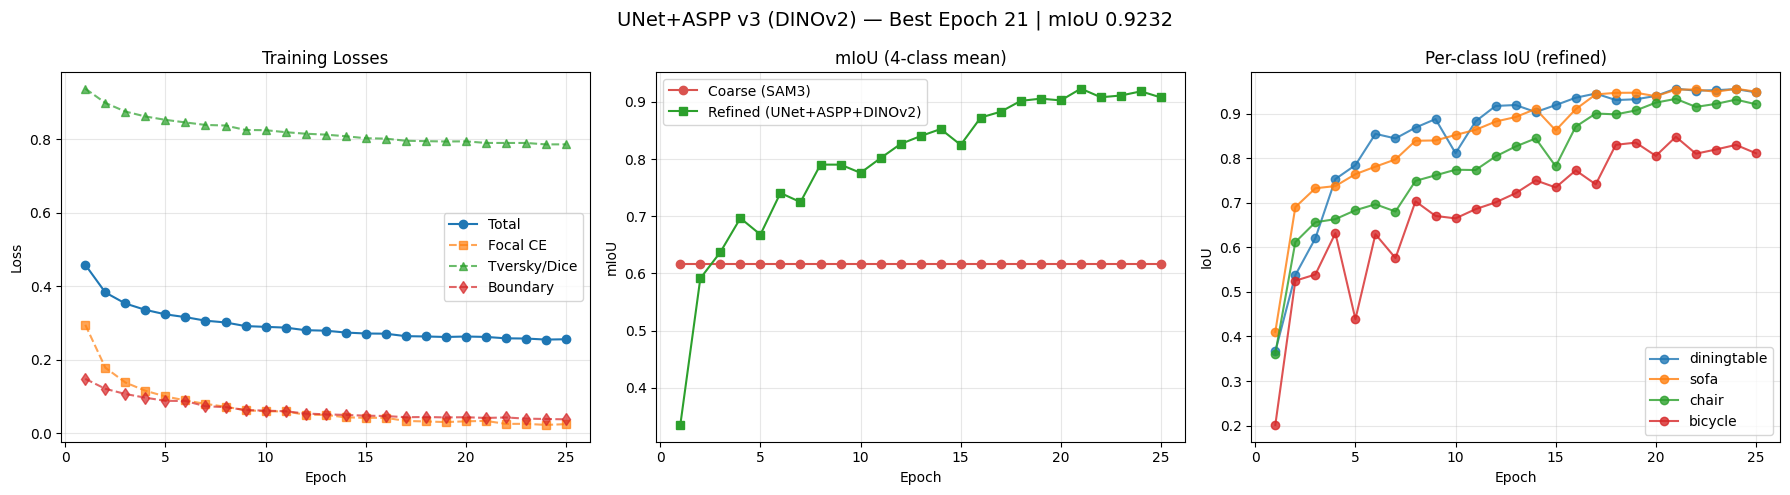

In [12]:
# ─── Plot training curves ──────────────────────────────────────────────────────
with open(HISTORY_JSON) as f:
    hist = json.load(f)

ep       = [r['epoch']       for r in hist]
tr_loss  = [r['train_loss']  for r in hist]
ce_v     = [r['ce']          for r in hist]
dice_v   = [r['dice']        for r in hist]
bnd_v    = [r['bnd']         for r in hist]
miou     = [r['miou']        for r in hist]
cmiou    = [r['coarse_miou'] for r in hist]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(ep, tr_loss, 'o-', label='Total')
axes[0].plot(ep, ce_v,    's--', label='Focal CE',     alpha=0.7)
axes[0].plot(ep, dice_v,  '^--', label='Tversky/Dice', alpha=0.7)
axes[0].plot(ep, bnd_v,   'd--', label='Boundary',     alpha=0.7)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Training Losses')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, cmiou, 'o-', label='Coarse (SAM3)', color='#d9534f')
axes[1].plot(ep, miou,  's-', label='Refined (UNet+ASPP+DINOv2)', color='#2ca02c')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('mIoU'); axes[1].set_title('mIoU (4-class mean)')
axes[1].legend(); axes[1].grid(alpha=0.3)

for cls in TARGET_CLASSES:
    pi = [r['per_iou'][cls] for r in hist]
    axes[2].plot(ep, pi, 'o-', label=cls, alpha=0.8)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('IoU'); axes[2].set_title('Per-class IoU (refined)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(f'UNet+ASPP v3 (DINOv2) — Best Epoch {best_epoch} | mIoU {best_miou:.4f}',
             fontsize=14)
plt.tight_layout()
plt.show()


## Tóm tắt notebook v3

### Thay đổi so với v2
1. **Thêm DINOv2 ViT-S/14 features** — frozen pretrained, ~21M params, cache 1 lần vào `dinov2_cache/`.
2. **Model nhận 2 input**: `input_8ch` (RGB+coarse+co_occ) + `dino_feat` (384×37×37 từ cache).
3. **DINOv2 compression branch**: 1x1 conv 384→32 (learned end-to-end) → upsample → concat với 8ch → ResNet first conv 40→64.
4. **HorizontalFlip** được handle thủ công để đồng bộ flip DINOv2 feature (axis=2).

### Giữ nguyên từ v2
- Per-class Tversky (sofa 0.4/0.6, bicycle 0.55/0.45, table/chair Dice).
- Focal CE γ=1.5.
- Sofa CE boost ×1.3.
- Boundary λ bicycle=2.0.
- 25 epochs, cosine LR, AdamW lr=1e-4.
- ResNet-34 encoder + ASPP(1,6,12,18,GAP) + UNet decoder + 5ch softmax.

### Checkpoint
- Path: `weights_aspp_new_v3/unet_aspp_new_v3_best.pth`
- `arch_version='multi_class_softmax_v3_dinov2'`
- Chứa đầy đủ config DINOv2 (model_name, embed_dim, patch_size, input_size, grid_size, compress) để eval notebook rebuild đúng.

### Eval
- `eval_5class_unet_aspp_new_v3.ipynb` — eval 5 weak classes (4 target + plant).
- `test-all-with-unetaspp-devin-v2-new_v3.ipynb` — eval 20 class full VOC.
- Cả 2 notebook eval đều **tính DINOv2 on-the-fly** (không cần cache trước) vì val chỉ 1449 ảnh (~30s DINOv2 overhead).

### Kỳ vọng
- **Chair, sofa** IoU tăng rõ rệt (fine-grained semantic discrimination).
- **Bicycle, table** giữ nguyên hoặc tốt hơn nhẹ.
- 20-class mIoU > 0.8345 (v2), kỳ vọng > 0.84.
